### CD8 Hallmark Gene Set Enrichment Analysis in R
*Dataset: PICA Batch001–Batch007 (PICA0001–PICA0128)* \
*Analysis: Hallmark pathway enrichment from CD8 pseudobulk DESeq2 results* \
**Subset focus:** TEM

#### Aim
This notebook performs Hallmark Gene Set Enrichment Analysis (GSEA) using age-associated DESeq2 pseudobulk results from CD8 T-cell subsets.

*Note: A full GSEA analysis had already been performed in Python across all CD8 subsets. This R-based analysis was therefore used as an independent validation step to double-check the pathway enrichment results.*

Genes are ranked using the DESeq2 test statistic, and preranked GSEA is performed using Hallmark gene sets through `fgsea`.

In [ ]:
library(msigdbr)
library(dplyr)
library(ggplot2)
library(fgsea)
library(purrr)
library(tibble)

deg_dir <- "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_DEG/CD8"
out_dir <- "/scratch/user/s4575250/BIOX7014_Thesis/Results/PICA_Batch001-Batch007/04_GSEA/CD8"

# Define CD8 subsets included in the GSEA validation analysis.
subsets <- c("CD8_GZMK__naive_Tcm", "CD8_Tem", "CD8_naive_Tcm")
walk(subsets, ~ dir.create(file.path(out_dir, .x), recursive = TRUE, showWarnings = FALSE))


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [ ]:
# Create a named list of DESeq2 result files
deg_files <- list(
  "CD8_GZMK__naive_Tcm"     = file.path(deg_dir, "DESeq2_age_CD8_GZMK__naive_Tcm.csv"),
  "CD8_Tem" = file.path(deg_dir, "DESeq2_age_CD8_Tem.csv"),
  "CD8_naive_Tcm"       = file.path(deg_dir, "DESeq2_age_CD8_naive_Tcm.csv")
)


In [3]:
# Load Hallmark gene sets
hallmark_raw <- readRDS("/scratch/user/s4575250/BIOX7014_Thesis/data/hallmark_msigdb.rds")
hallmark <- split(x = hallmark_raw$gene_symbol, f = hallmark_raw$gs_name)

In [ ]:
# Define function to run preranked GSEA
run_gsea <- function(filepath, cell_type) {
  # Read DESeq2 results for the selected subset
  res <- read.csv(filepath)
  
  # Prepare ranked gene list for preranked GSEA
  # Genes with missing names or statistics are removed  
  ranked <- res %>%
    filter(!is.na(stat) & !is.na(gene)) %>%
    arrange(desc(stat)) %>%
    dplyr::select(gene, stat) %>%
    deframe()
  
  # Run preranked GSEA using Hallmark gene sets
  set.seed(33)
  gsea_res <- fgsea(
    pathways    = hallmark,
    stats       = ranked,
    minSize     = 15,
    maxSize     = 500,
    nPermSimple = 10000
  ) %>%
    mutate(
      cell_type = cell_type,
      direction = case_when(
        NES > 0 & padj < 0.05 ~ "Up with age",
        NES < 0 & padj < 0.05 ~ "Down with age",
        TRUE ~ "Not significant"
      ),
      pathway = gsub("HALLMARK_", "", pathway),
      pathway = gsub("_", " ", pathway)
    )
  
  # Convert leading-edge genes into a single text string so the results
  gsea_res_save <- gsea_res %>%
    mutate(leadingEdge = sapply(leadingEdge, paste, collapse = ";"))
  
  subset_dir <- file.path(out_dir, cell_type)
  
  # Save the full GSEA result table
  write.csv(gsea_res_save,
            file.path(subset_dir, paste0("CD8_GSEA_Hallmark_", cell_type, "_full.csv")),
            row.names = FALSE)
  
  # Save only pathways significant after FDR correction
  write.csv(filter(gsea_res_save, padj < 0.05),
            file.path(subset_dir, paste0("CD8_GSEA_Hallmark_", cell_type, "_significant.csv")),
            row.names = FALSE)
  
  # Extract significant pathways for plotting
  sig <- gsea_res %>% filter(padj < 0.05) %>% arrange(NES)
  
  # Generate a pathway bar plot only if significant pathways are detected
  if (nrow(sig) > 0) {
    p <- ggplot(sig, aes(x = NES, y = reorder(pathway, NES))) +
      geom_bar(stat = "identity", fill = "#2196F3") +
      labs(
        title = paste(cell_type, "Hallmark GSEA pathways"),
        x     = "Normalized Enrichment Score (NES)",
        y     = "Hallmark pathway"
      ) +
      theme_classic() +
      theme(
        axis.text.y = element_text(size = 10),
        plot.title  = element_text(hjust = 0.5)
      )
    
    ggsave(file.path(subset_dir, paste0("GSEA_top_pathways_", cell_type, ".png")),
           p, width = 8, height = 6, dpi = 300)
  } else {
    message("No significant pathways for: ", cell_type)
  }
  
  return(gsea_res)  # return list version for downstream use
}
          

In [ ]:
# Run GSEA across all subsets
gsea_all <- imap_dfr(deg_files, ~ run_gsea(.x, .y))


In [ ]:
# Convert leading-edge genes into text format for saving
gsea_all_save <- gsea_all %>%
  mutate(leadingEdge = sapply(leadingEdge, paste, collapse = ";"))

# Save all Hallmark GSEA results across CD4 subsets.
write.csv(gsea_all_save,
          file.path(out_dir, "CD8_GSEA_Hallmark_combined.csv"),
          row.names = FALSE)

# Save only significant pathways across all CD4 subsets.
write.csv(filter(gsea_all_save, padj < 0.05),
          file.path(out_dir, "CD8_GSEA_Hallmark_significant.csv"),
          row.names = FALSE)

# Summary table: NES per pathway per subset
summary_wide <- gsea_all %>%
  filter(padj < 0.05) %>%
  dplyr::select(pathway, cell_type, NES) %>%
  tidyr::pivot_wider(names_from = cell_type, values_from = NES)

write.csv(summary_wide,
          file.path(out_dir, "CD8_GSEA_Hallmark_summary.csv"),
          row.names = FALSE)


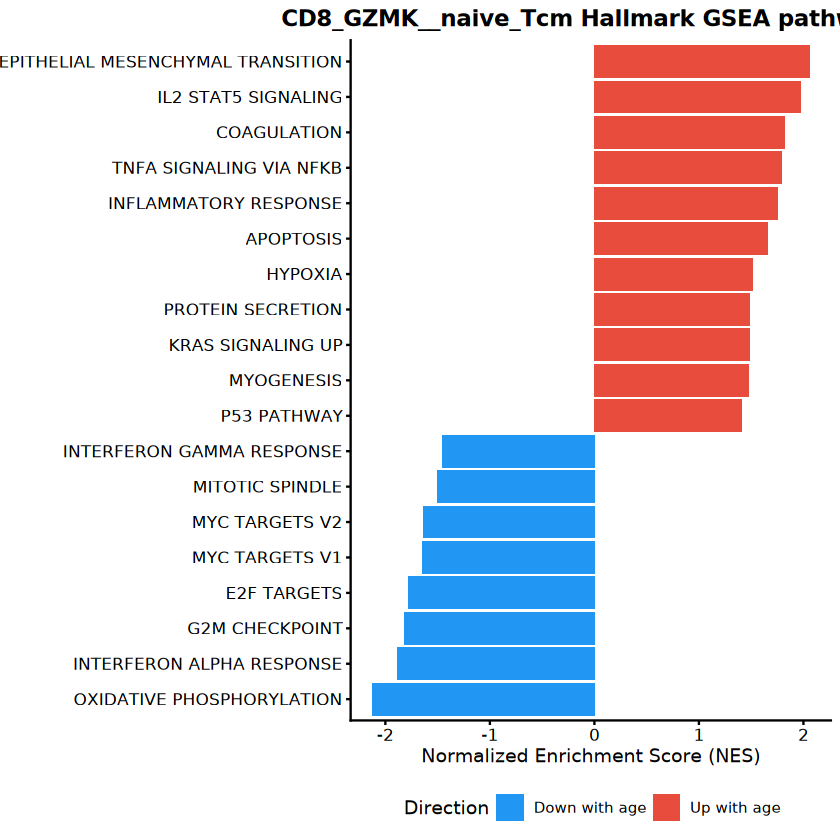

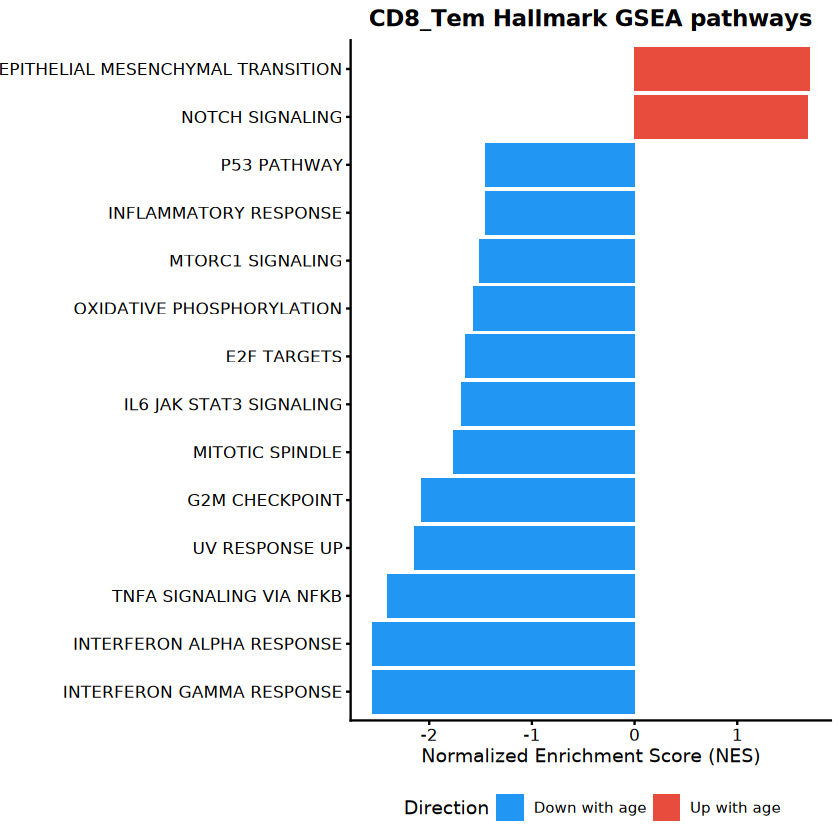

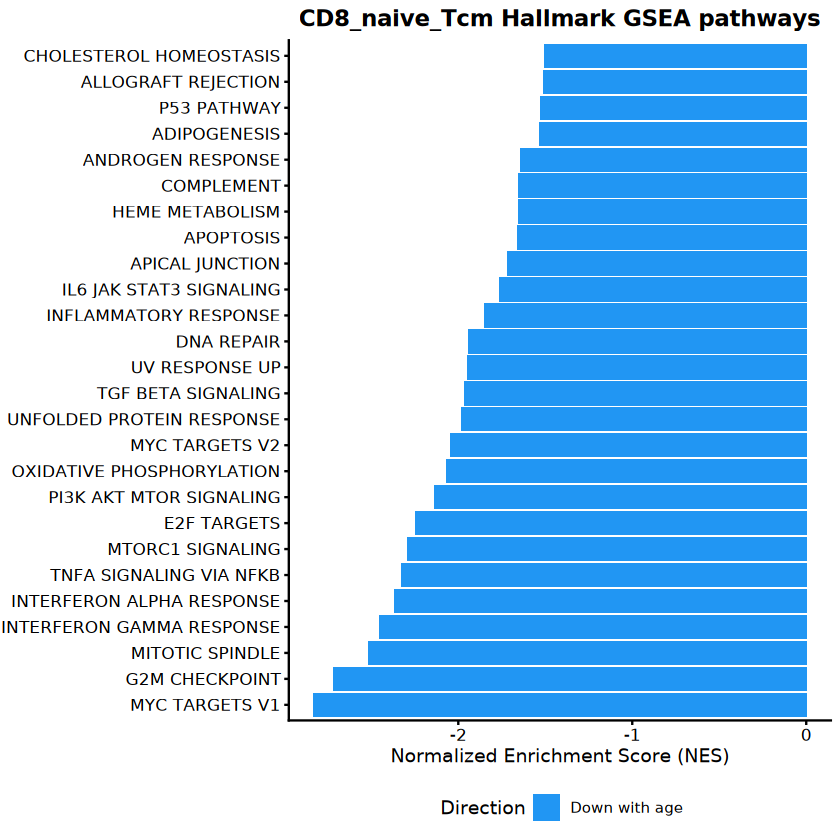

In [ ]:
# Visualise significant Hallmark pathways for each subset
plots <- map(unique(gsea_all$cell_type), function(ct) {
  
  sig <- gsea_all %>%
    filter(padj < 0.05, cell_type == ct) %>%
    arrange(NES)
  
  if (nrow(sig) == 0) {
    message("No significant pathways for: ", ct)
    return(NULL)
  }
  
  ggplot(sig, aes(x = NES, y = reorder(pathway, NES), fill = direction)) +
    geom_bar(stat = "identity") +
    scale_fill_manual(values = c("Up with age"   = "#E74C3C",
                                 "Down with age" = "#2196F3")) +
    labs(
      title = paste(ct, "Hallmark GSEA pathways"),
      x     = "Normalized Enrichment Score (NES)",
      y     = NULL,
      fill  = "Direction"
    ) +
    theme_classic() +
    theme(
      axis.text.y     = element_text(size = 10),
      axis.text.x     = element_text(size = 10),
      plot.title      = element_text(hjust = 0.5, face = "bold"),
      legend.position = "bottom"
    )
})

# Display each plot 
for (p in plots) {
  if (!is.null(p)) print(p)
}